# 1. Environment Configuration & Dataset Ingestion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ingest student placement records from local storage or direct repository link
dataset_path = '../../Datasets/placement.csv'
try:
    placement_df = pd.read_csv(dataset_path)
except Exception:
    placement_df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day42-outlier-removal-using-zscore/placement.csv')

placement_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


# 2. Exploratory Dataset Profiling

In [2]:
print("Dataset dimensions (rows, columns):", placement_df.shape)
placement_df.describe()

Dataset dimensions (rows, columns): (1000, 3)


,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


# 3. Pre-Cleaning Feature Distribution & Outlier Visualization

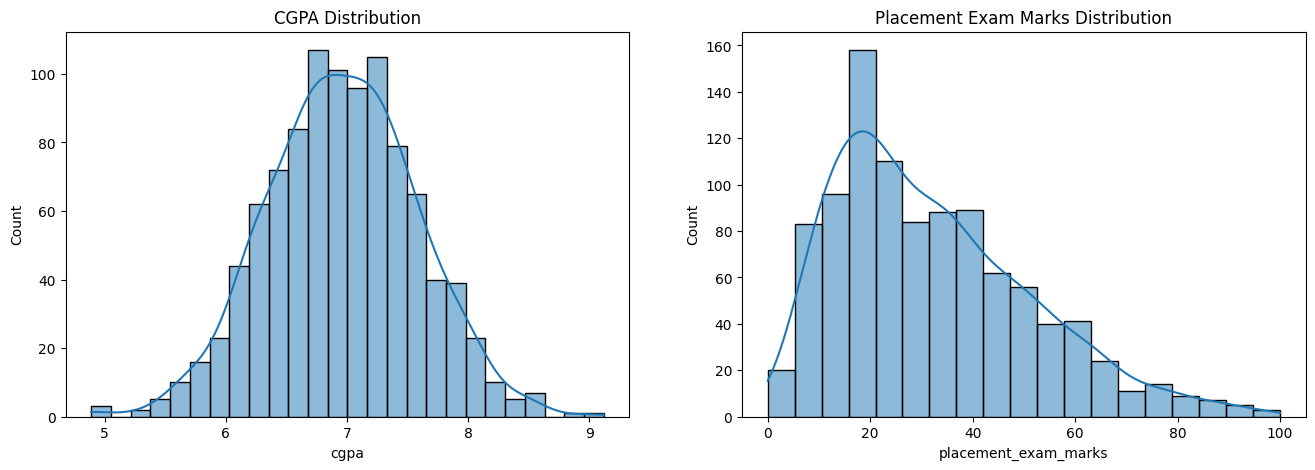

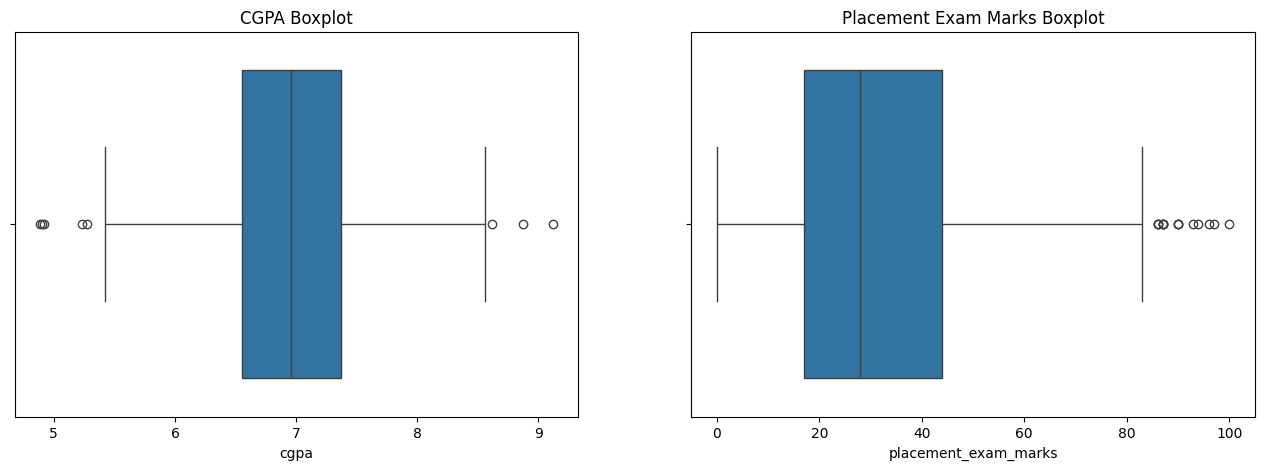

In [3]:
# Histograms with Kernel Density Estimation (KDE)
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(placement_df['cgpa'], kde=True, color='tab:blue')
plt.title("CGPA Distribution")
plt.xlabel("cgpa")

plt.subplot(1, 2, 2)
sns.histplot(placement_df['placement_exam_marks'], kde=True, color='tab:blue')
plt.title("Placement Exam Marks Distribution")
plt.xlabel("placement_exam_marks")
plt.show()

# Boxplots for assessing spread and identifying extreme values
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=placement_df['cgpa'], color='tab:blue')
plt.title("CGPA Boxplot")

plt.subplot(1, 2, 2)
sns.boxplot(x=placement_df['placement_exam_marks'], color='tab:blue')
plt.title("Placement Exam Marks Boxplot")
plt.show()

# 4. Standard Score (Z-Score) Derivation & Outlier Detection

In [4]:
# Compute Z-score based on sample mean and sample standard deviation
cgpa_mean = placement_df['cgpa'].mean()
cgpa_std = placement_df['cgpa'].std()
placement_df['cgpa_zscore'] = (placement_df['cgpa'] - cgpa_mean) / cgpa_std

# Identify records lying beyond 3 standard deviations (|Z| > 3)
flagged_outliers = placement_df[(placement_df['cgpa_zscore'] > 3) | (placement_df['cgpa_zscore'] < -3)]
flagged_outliers

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


# 5. Outlier Trimming & Cleaned Subset Creation

In [5]:
# Filter dataset to retain entries within the [-3, 3] standard score boundary
cleaned_df = placement_df[(placement_df['cgpa_zscore'] < 3) & (placement_df['cgpa_zscore'] > -3)].copy()
print("Original shape:", placement_df.shape)
print("New shape:", cleaned_df.shape)

Original shape: (1000, 4)
New shape: (995, 4)


# 6. Side-by-Side Distribution & Boxplot Comparison

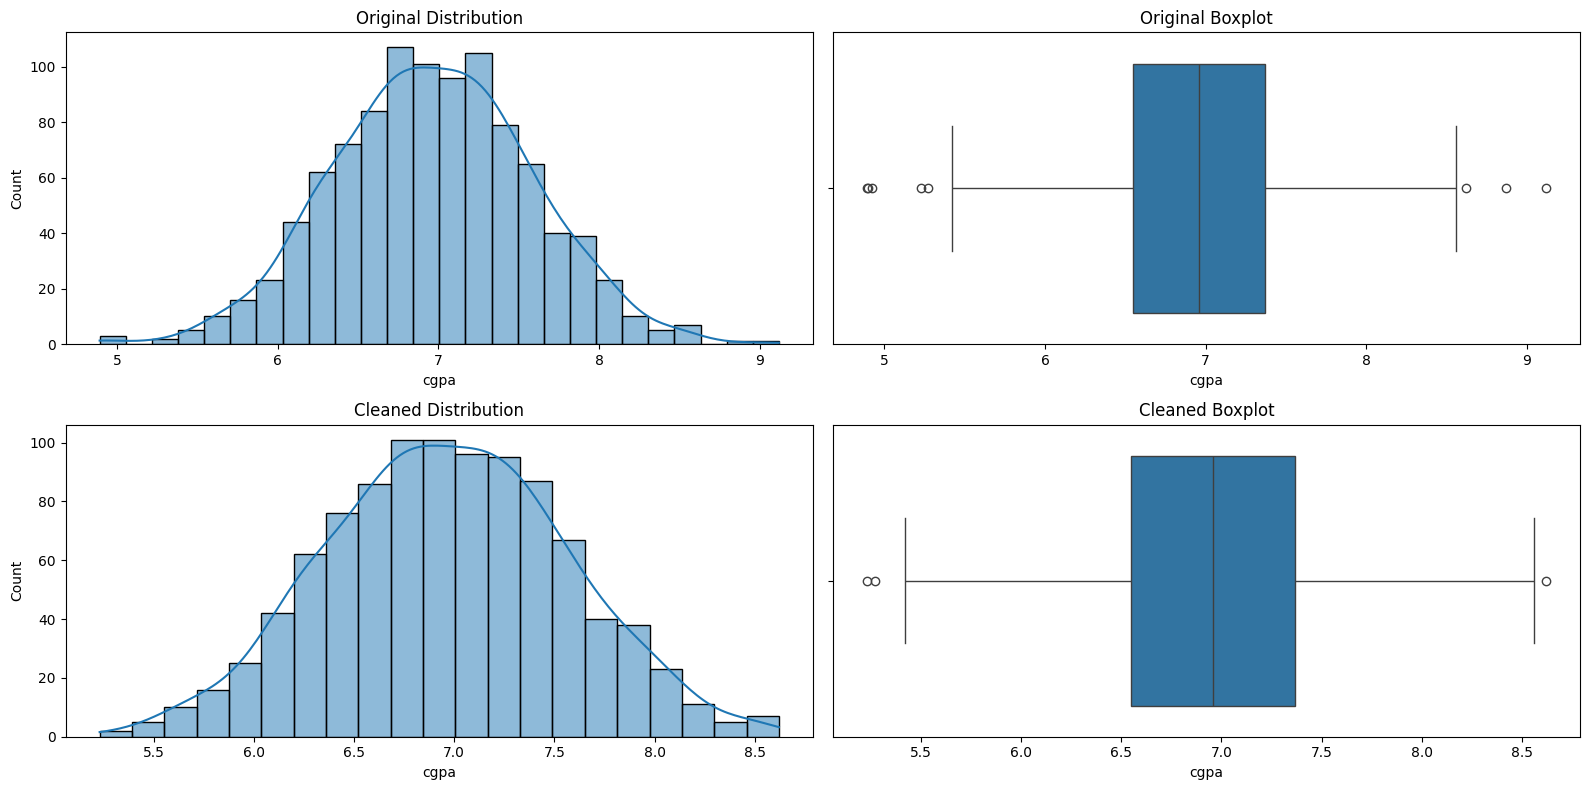

In [6]:
plt.figure(figsize=(16, 8))

# Original data distribution and spread
plt.subplot(2, 2, 1)
sns.histplot(placement_df['cgpa'], kde=True, color='tab:blue')
plt.title("Original Distribution")

plt.subplot(2, 2, 2)
sns.boxplot(x=placement_df['cgpa'], color='tab:blue')
plt.title("Original Boxplot")

# Cleaned data distribution and spread
plt.subplot(2, 2, 3)
sns.histplot(cleaned_df['cgpa'], kde=True, color='tab:blue')
plt.title("Cleaned Distribution")

plt.subplot(2, 2, 4)
sns.boxplot(x=cleaned_df['cgpa'], color='tab:blue')
plt.title("Cleaned Boxplot")

plt.tight_layout()
plt.show()